In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_parquet("/Users/alex/Downloads/esa-adb-challenge (1)/train.parquet")
print(df.shape)
print(df.dtypes)
df.head(5)

(14728321, 89)
id                   int64
channel_1          float32
channel_10         float32
channel_11         float32
channel_12         float32
                    ...   
telecommand_376    float64
telecommand_38     float64
telecommand_39     float64
telecommand_40     float64
is_anomaly           uint8
Length: 89, dtype: object


,id,channel_1,channel_10,channel_11,channel_12,channel_13,channel_14,channel_15,channel_16,channel_17,...,telecommand_351,telecommand_352,telecommand_353,telecommand_354,telecommand_36,telecommand_376,telecommand_38,telecommand_39,telecommand_40,is_anomaly
0,0,0.13791,0.0,0.0,0.317175,0.371764,0.297205,0.130113,0.766769,0.349474,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,1,0.13791,0.0,0.0,0.317175,0.371764,0.297205,0.130113,0.766769,0.349474,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,2,0.13791,0.0,0.0,0.317175,0.371764,0.297205,0.130113,0.766769,0.349474,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,3,0.13791,0.0,0.0,0.317175,0.371764,0.297205,0.130113,0.766769,0.349474,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,4,0.13791,0.0,0.0,0.317175,0.371764,0.297205,0.130113,0.766769,0.349474,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [4]:
print(df.shape)
print(df.columns.tolist())

(14728321, 89)
['id', 'channel_1', 'channel_10', 'channel_11', 'channel_12', 'channel_13', 'channel_14', 'channel_15', 'channel_16', 'channel_17', 'channel_18', 'channel_19', 'channel_2', 'channel_20', 'channel_21', 'channel_22', 'channel_23', 'channel_24', 'channel_25', 'channel_26', 'channel_27', 'channel_28', 'channel_29', 'channel_3', 'channel_30', 'channel_31', 'channel_32', 'channel_33', 'channel_34', 'channel_35', 'channel_36', 'channel_37', 'channel_38', 'channel_39', 'channel_4', 'channel_40', 'channel_41', 'channel_42', 'channel_43', 'channel_44', 'channel_45', 'channel_46', 'channel_47', 'channel_48', 'channel_49', 'channel_5', 'channel_50', 'channel_51', 'channel_52', 'channel_53', 'channel_54', 'channel_55', 'channel_56', 'channel_57', 'channel_58', 'channel_59', 'channel_6', 'channel_60', 'channel_61', 'channel_62', 'channel_63', 'channel_64', 'channel_65', 'channel_66', 'channel_67', 'channel_68', 'channel_69', 'channel_7', 'channel_70', 'channel_71', 'channel_72', 'chan

In [5]:
print(df.dtypes)
print(df.isnull().sum())

id                   int64
channel_1          float32
channel_10         float32
channel_11         float32
channel_12         float32
                    ...   
telecommand_376    float64
telecommand_38     float64
telecommand_39     float64
telecommand_40     float64
is_anomaly           uint8
Length: 89, dtype: object
id                 0
channel_1          0
channel_10         0
channel_11         0
channel_12         0
                  ..
telecommand_376    0
telecommand_38     0
telecommand_39     0
telecommand_40     0
is_anomaly         0
Length: 89, dtype: int64


In [6]:
df['is_anomaly'].value_counts(normalize=True)

is_anomaly
0    0.895161
1    0.104839
Name: proportion, dtype: float64

EDA

In [ ]:
cols = ['id', 'channel_41', 'channel_42', 'channel_43',
        'channel_44', 'channel_45', 'channel_46', 'is_anomaly']

df_small = df[cols].copy()
print(df_small.shape)
df_small.head()

In [8]:
df_small.describe()

,id,channel_41,channel_42,channel_43,channel_44,channel_45,channel_46,is_anomaly
count,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07
mean,7.364160e+06,8.082077e-01,7.821209e-01,7.685694e-01,7.940099e-01,8.103804e-01,7.656219e-01,1.048391e-01
std,4.251700e+06,3.117312e-02,3.104107e-02,3.194150e-02,3.466514e-02,3.144005e-02,3.055148e-02,3.063460e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.682080e+06,8.055143e-01,7.783114e-01,7.663610e-01,7.913063e-01,8.066803e-01,7.610731e-01,0.000000e+00
50%,7.364160e+06,8.094388e-01,7.831301e-01,7.703173e-01,7.960299e-01,8.117668e-01,7.669848e-01,0.000000e+00
75%,1.104624e+07,8.141486e-01,7.895566e-01,7.742736e-01,8.007520e-01,8.168547e-01,7.728950e-01,0.000000e+00
max,1.472832e+07,9.821104e-01,9.662727e-01,9.507276e-01,9.755059e-01,1.000000e+00,9.595303e-01,1.000000e+00


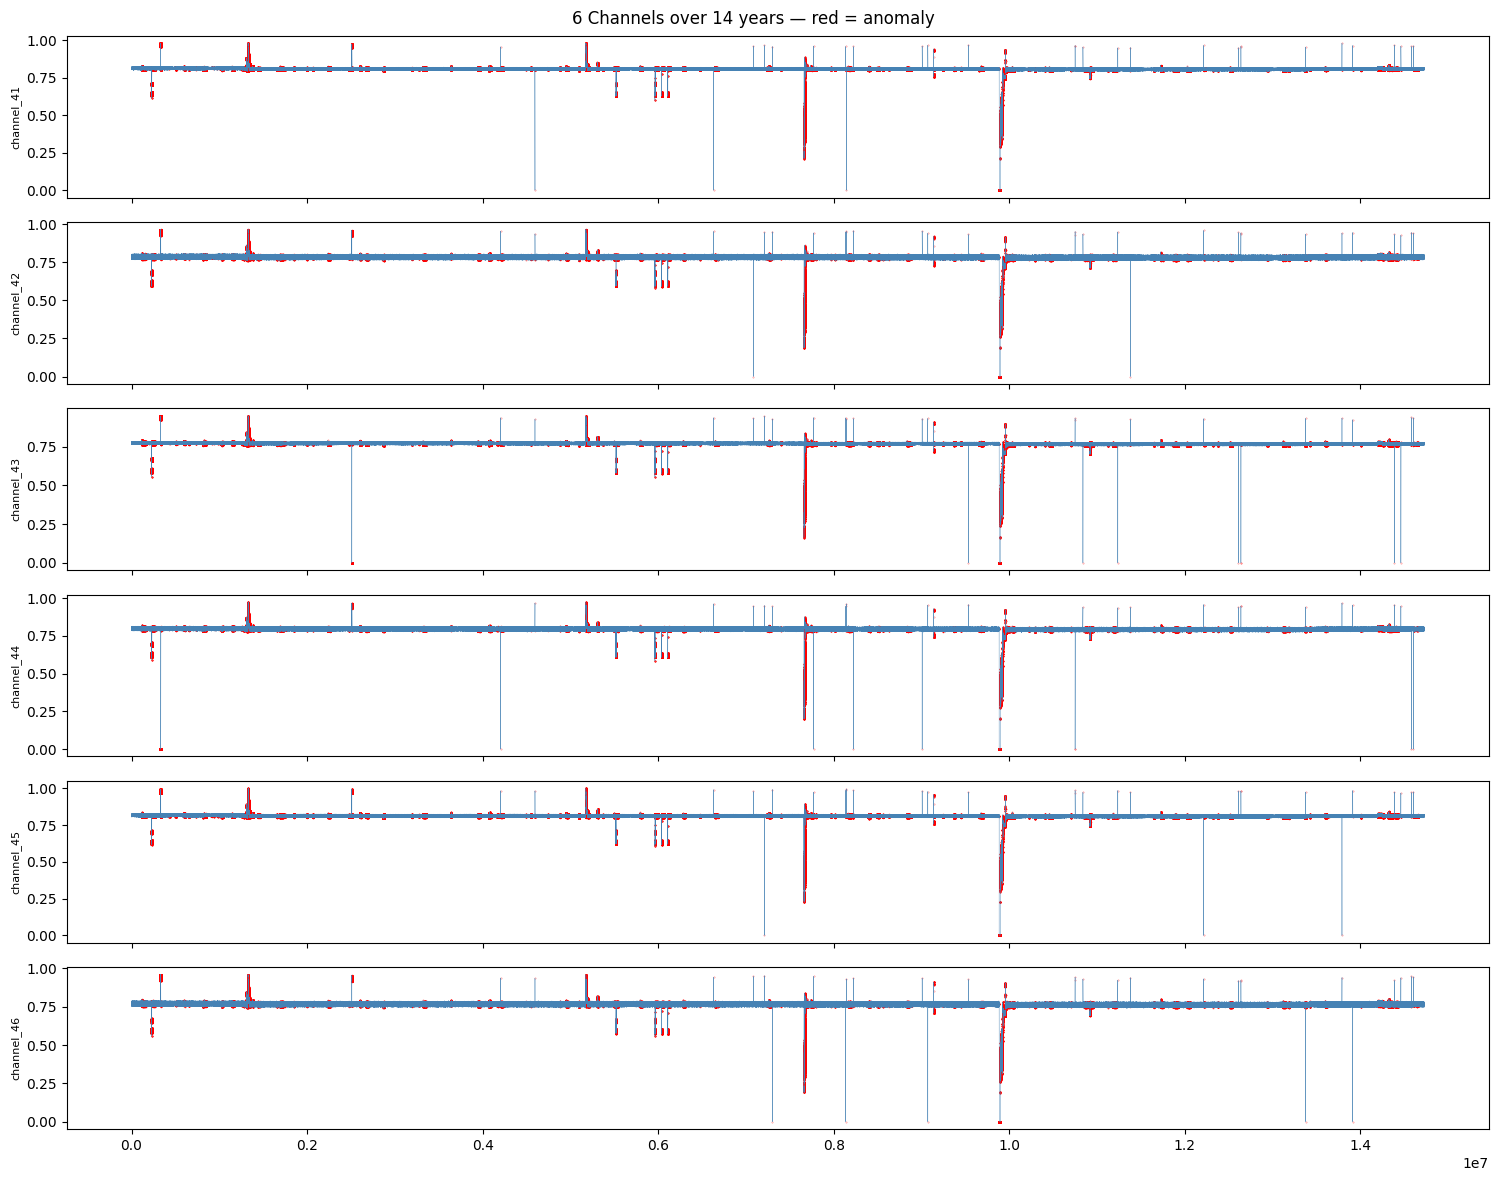

In [9]:
fig, axes = plt.subplots(6, 1, figsize=(15, 12), sharex=True)

channels = ['channel_41', 'channel_42', 'channel_43',
            'channel_44', 'channel_45', 'channel_46']

for i, col in enumerate(channels):
    axes[i].plot(df_small['id'], df_small[col], linewidth=0.3, color='steelblue')
    # Highlight anomalies in red
    anomalies = df_small[df_small['is_anomaly'] == 1]
    axes[i].scatter(anomalies['id'], anomalies[col],
                    color='red', s=0.1, alpha=0.5)
    axes[i].set_ylabel(col, fontsize=8)

plt.suptitle('6 Channels over 14 years — red = anomaly')
plt.tight_layout()
plt.show()

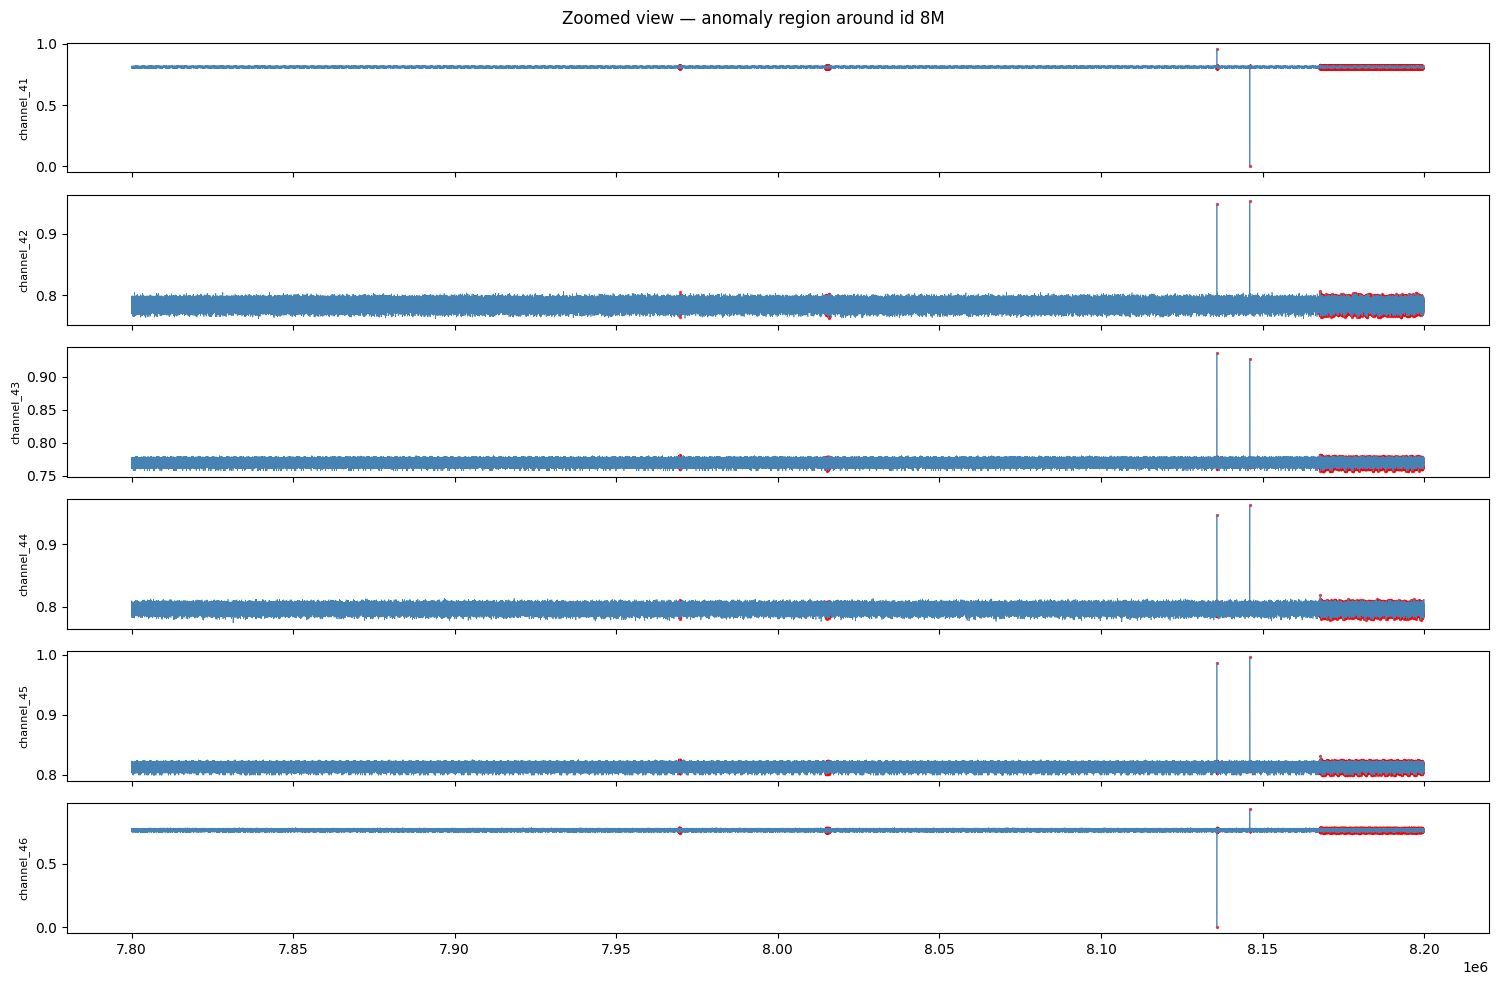

In [ ]:
# Zooming into one anomaly region - around id 8,000,000
mask = (df_small['id'] > 7_800_000) & (df_small['id'] < 8_200_000)
zoom = df_small[mask]

fig, axes = plt.subplots(6, 1, figsize=(15, 10), sharex=True)

for i, col in enumerate(channels):
    axes[i].plot(zoom['id'], zoom[col], linewidth=0.5, color='steelblue')
    anomalies = zoom[zoom['is_anomaly'] == 1]
    axes[i].scatter(anomalies['id'], anomalies[col],
                    color='red', s=2, alpha=0.7)
    axes[i].set_ylabel(col, fontsize=8)

plt.suptitle('Zoomed view — anomaly region around id 8M')
plt.tight_layout()
plt.show()

In [11]:
# Count distinct anomaly events
df_small['event'] = (df_small['is_anomaly'] != df_small['is_anomaly'].shift()).cumsum()
anomaly_events = df_small[df_small['is_anomaly'] == 1].groupby('event').size()

print(f"Number of anomaly events: {len(anomaly_events)}")
print(f"Event duration stats (in timesteps):")
print(anomaly_events.describe())

/var/folders/46/xpl_gkfs06x2k07qpdsjl6r80000gn/T/ipykernel_26296/761958101.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_small['event'] = (df_small['is_anomaly'] != df_small['is_anomaly'].shift()).cumsum()


Number of anomaly events: 190
Event duration stats (in timesteps):
count       190.000000
mean       8126.863158
std       15114.108367
min           1.000000
25%          25.000000
50%         601.500000
75%        9081.000000
max      116061.000000
dtype: float64


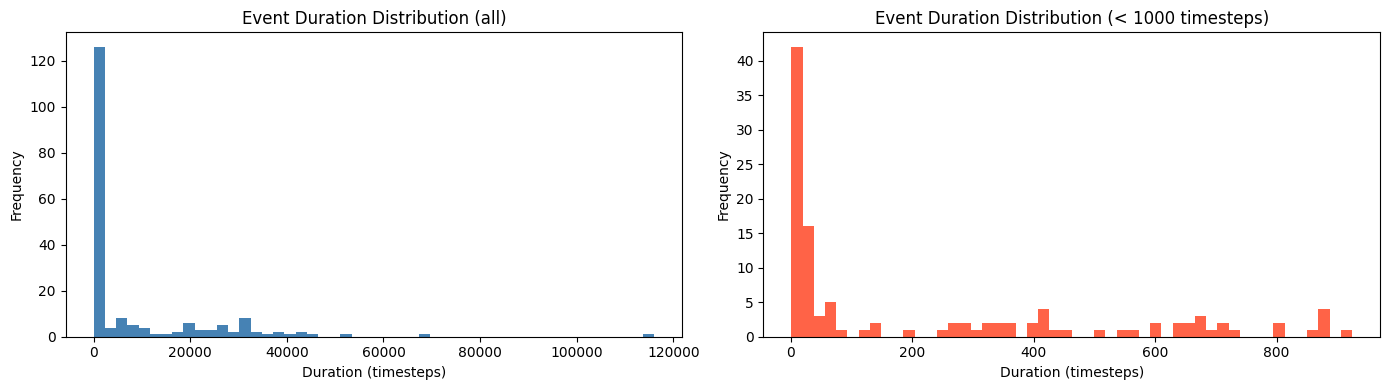

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Full distribution
anomaly_events.plot(kind='hist', bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Event Duration Distribution (all)')
axes[0].set_xlabel('Duration (timesteps)')

# Zoomed - under 1000 timesteps
anomaly_events[anomaly_events < 1000].plot(kind='hist', bins=50, ax=axes[1], color='tomato')
axes[1].set_title('Event Duration Distribution (< 1000 timesteps)')
axes[1].set_xlabel('Duration (timesteps)')

plt.tight_layout()
plt.show()

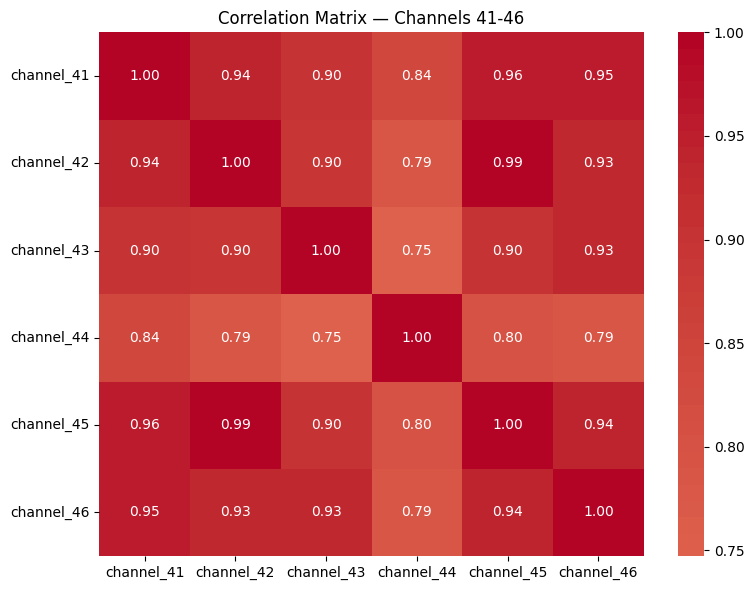

In [13]:
# Correlation matrix of the 6 channels
fig, ax = plt.subplots(figsize=(8, 6))

corr = df_small[channels].corr()

sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            ax=ax)

plt.title('Correlation Matrix — Channels 41-46')
plt.tight_layout()
plt.show()

## Z-score threshold

In [14]:
from scipy import stats

channels = ['channel_41', 'channel_42', 'channel_43',
            'channel_44', 'channel_45', 'channel_46']

# Calculate z-score for each channel
z_scores = df_small[channels].apply(stats.zscore)

# Flag as anomaly if ANY channel exceeds threshold
threshold = 3  # 3 standard deviations
df_small['pred_anomaly'] = (z_scores.abs() > threshold).any(axis=1).astype(int)

# Check how many we're flagging
print(df_small['pred_anomaly'].value_counts(normalize=True))
print(df_small['pred_anomaly'].value_counts())

pred_anomaly
0    0.994744
1    0.005256
Name: proportion, dtype: float64
pred_anomaly
0    14650905
1       77416
Name: count, dtype: int64


/var/folders/46/xpl_gkfs06x2k07qpdsjl6r80000gn/T/ipykernel_26296/903852414.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_small['pred_anomaly'] = (z_scores.abs() > threshold).any(axis=1).astype(int)


In [15]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(df_small['is_anomaly'], df_small['pred_anomaly']))
print(confusion_matrix(df_small['is_anomaly'], df_small['pred_anomaly']))

              precision    recall  f1-score   support

           0       0.90      1.00      0.95  13184217
           1       1.00      0.05      0.10   1544104

    accuracy                           0.90  14728321
   macro avg       0.95      0.53      0.52  14728321
weighted avg       0.91      0.90      0.86  14728321

[[13184217        0]
 [ 1466688    77416]]


In [16]:
# Check how many EVENTS we detected
df_small['event'] = (df_small['is_anomaly'] != df_small['is_anomaly'].shift()).cumsum()

# For each anomaly event, did we detect at least one point?
events = df_small[df_small['is_anomaly'] == 1].groupby('event')['pred_anomaly'].max()

print(f"Total anomaly events: {len(events)}")
print(f"Events detected (at least 1 point): {events.sum()}")
print(f"Events missed: {len(events) - events.sum()}")
print(f"Event-wise recall: {events.sum() / len(events):.2%}")

/var/folders/46/xpl_gkfs06x2k07qpdsjl6r80000gn/T/ipykernel_26296/650306877.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_small['event'] = (df_small['is_anomaly'] != df_small['is_anomaly'].shift()).cumsum()


Total anomaly events: 190
Events detected (at least 1 point): 39
Events missed: 151
Event-wise recall: 20.53%


In [17]:
for thresh in [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]:
    z = (z_scores.abs() > thresh).any(axis=1).astype(int)
    events_detected = df_small[df_small['is_anomaly'] == 1].copy()
    events_detected['pred'] = z[events_detected.index]
    detected = events_detected.groupby('event')['pred'].max().sum()
    fp = z[(df_small['is_anomaly'] == 0)].sum()
    print(f"Threshold {thresh}: events detected={detected}/190, false positive points={fp:,}")

Threshold 0.5: events detected=166/190, false positive points=377,444
Threshold 1.0: events detected=46/190, false positive points=0
Threshold 1.5: events detected=41/190, false positive points=0
Threshold 2.0: events detected=40/190, false positive points=0
Threshold 2.5: events detected=39/190, false positive points=0
Threshold 3.0: events detected=39/190, false positive points=0


## Isolation Forrest

In [18]:
from sklearn.ensemble import IsolationForest

# Use only the 6 channels as features
X = df_small[channels].values

# Train Isolation Forest
# contamination = expected proportion of anomalies
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.105,  # we know ~10.5% are anomalies
    random_state=42,
    n_jobs=-1  # use all CPU cores
)

print("Training Isolation Forest...")
iso_forest.fit(X)
print("Done!")

Training Isolation Forest...


python(34105) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Done!


In [19]:
# Get predictions (-1 = anomaly, 1 = normal in sklearn)
preds = iso_forest.predict(X)

# Convert to 0/1 format (1 = anomaly, 0 = normal)
df_small['pred_iso'] = (preds == -1).astype(int)

# Basic counts
print(df_small['pred_iso'].value_counts(normalize=True))
print(df_small['pred_iso'].value_counts())

/var/folders/46/xpl_gkfs06x2k07qpdsjl6r80000gn/T/ipykernel_26296/582683755.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_small['pred_iso'] = (preds == -1).astype(int)


pred_iso
0    0.895
1    0.105
Name: proportion, dtype: float64
pred_iso
0    13181847
1     1546474
Name: count, dtype: int64


In [20]:
# Event-wise evaluation
events_iso = df_small[df_small['is_anomaly'] == 1].groupby('event')['pred_iso'].max()

print(f"\nTotal anomaly events: {len(events_iso)}")
print(f"Events detected: {events_iso.sum()}")
print(f"Events missed: {len(events_iso) - events_iso.sum()}")
print(f"Event-wise recall: {events_iso.sum() / len(events_iso):.2%}")

# False positives
fp = df_small[(df_small['is_anomaly'] == 0) & (df_small['pred_iso'] == 1)].shape[0]
print(f"False positive points: {fp:,}")


Total anomaly events: 190
Events detected: 176
Events missed: 14
Event-wise recall: 92.63%
False positive points: 1,177,480


In [21]:
for cont in [0.01, 0.02, 0.05, 0.08, 0.10, 0.15]:
    iso = IsolationForest(
        n_estimators=100,
        contamination=cont,
        random_state=42,
        n_jobs=-1
    )
    iso.fit(X)
    p = (iso.predict(X) == -1).astype(int)

    events_detected = df_small[df_small['is_anomaly'] == 1].copy()
    events_detected['pred'] = p[events_detected.index]
    detected = events_detected.groupby('event')['pred'].max().sum()
    fp = ((df_small['is_anomaly'] == 0) & (p == 1)).sum()

    print(f"Contamination {cont}: events={detected}/190, FP={fp:,}")

Contamination 0.01: events=43/190, FP=0
Contamination 0.02: events=131/190, FP=95,509
Contamination 0.05: events=163/190, FP=470,815
Contamination 0.08: events=172/190, FP=854,493
Contamination 0.1: events=173/190, FP=1,112,635
Contamination 0.15: events=180/190, FP=1,764,079


In [22]:
# Load test data
df_test = pd.read_parquet("/Users/alex/Downloads/esa-adb-challenge (1)/test.parquet")
print(df_test.shape)
print(df_test.columns.tolist())
df_test.head()

(521280, 88)
['id', 'channel_1', 'channel_10', 'channel_11', 'channel_12', 'channel_13', 'channel_14', 'channel_15', 'channel_16', 'channel_17', 'channel_18', 'channel_19', 'channel_2', 'channel_20', 'channel_21', 'channel_22', 'channel_23', 'channel_24', 'channel_25', 'channel_26', 'channel_27', 'channel_28', 'channel_29', 'channel_3', 'channel_30', 'channel_31', 'channel_32', 'channel_33', 'channel_34', 'channel_35', 'channel_36', 'channel_37', 'channel_38', 'channel_39', 'channel_4', 'channel_40', 'channel_41', 'channel_42', 'channel_43', 'channel_44', 'channel_45', 'channel_46', 'channel_47', 'channel_48', 'channel_49', 'channel_5', 'channel_50', 'channel_51', 'channel_52', 'channel_53', 'channel_54', 'channel_55', 'channel_56', 'channel_57', 'channel_58', 'channel_59', 'channel_6', 'channel_60', 'channel_61', 'channel_62', 'channel_63', 'channel_64', 'channel_65', 'channel_66', 'channel_67', 'channel_68', 'channel_69', 'channel_7', 'channel_70', 'channel_71', 'channel_72', 'channe

,id,channel_1,channel_10,channel_11,channel_12,channel_13,channel_14,channel_15,channel_16,channel_17,...,telecommand_350,telecommand_351,telecommand_352,telecommand_353,telecommand_354,telecommand_36,telecommand_376,telecommand_38,telecommand_39,telecommand_40
0,14728321,0.13791,0.0,0.0,0.218915,0.270384,0.63107,0.314563,0.786995,0.265045,...,0,0,0,0,0.0,0.0,0,0.0,0.0,0.0
1,14728322,0.13791,0.0,0.0,0.218915,0.270384,0.63107,0.314563,0.786995,0.265045,...,0,0,0,0,0.0,0.0,0,0.0,0.0,0.0
2,14728323,0.13791,0.0,0.0,0.218915,0.270384,0.63107,0.314563,0.786995,0.265045,...,0,0,0,0,0.0,0.0,0,0.0,0.0,0.0
3,14728324,0.13791,0.0,0.0,0.218915,0.270384,0.63107,0.314563,0.786995,0.265045,...,0,0,0,0,0.0,0.0,0,0.0,0.0,0.0
4,14728325,0.13791,0.0,0.0,0.218915,0.270384,0.63107,0.314563,0.786995,0.265045,...,0,0,0,0,0.0,0.0,0,0.0,0.0,0.0


In [23]:
# Extract the same 6 channels from test
X_test = df_test[channels].values

# Use our best model (contamination=0.02)
iso_best = IsolationForest(
    n_estimators=100,
    contamination=0.02,
    random_state=42,
    n_jobs=-1
)

# Train on training data
iso_best.fit(X)

# Predict on test data
test_preds = iso_best.predict(X_test)

# Convert to 0/1
df_test['is_anomaly'] = (test_preds == -1).astype(int)

# Check prediction distribution
print(df_test['is_anomaly'].value_counts(normalize=True))
print(df_test['is_anomaly'].value_counts())

is_anomaly
0    0.990684
1    0.009316
Name: proportion, dtype: float64
is_anomaly
0    516424
1      4856
Name: count, dtype: int64


In [24]:
# Create submission dataframe
submission = df_test[['id', 'is_anomaly']].copy()

# Verify format matches sample submission
sample = pd.read_parquet("/Users/alex/Downloads/esa-adb-challenge (1)/sample_submission.parquet")
print("Sample submission format:")
print(sample.head())
print(sample.shape)
print("\nOur submission format:")
print(submission.head())
print(submission.shape)

Sample submission format:
         id  is_anomaly
0  14728321           0
1  14728322           0
2  14728323           0
3  14728324           0
4  14728325           0
(521280, 2)

Our submission format:
         id  is_anomaly
0  14728321           0
1  14728322           0
2  14728323           0
3  14728324           0
4  14728325           0
(521280, 2)


In [25]:
# Save as parquet (recommended by competition)
submission.to_parquet("/Users/alex/Downloads/submission_isolation_forest_002.parquet", index=False)
print("Saved!")

Saved!


In [26]:
# Remove isolated predictions - only keep anomalies
# that have neighbors within N timesteps
from scipy.ndimage import uniform_filter1d

preds_array = df_test['is_anomaly'].values

# Only keep detections that are part of a cluster
window = 5  # must have anomalies within 5 timesteps
smoothed = uniform_filter1d(preds_array.astype(float), size=window)
df_test['is_anomaly_clean'] = (smoothed > 0.3).astype(int)

print(df_test['is_anomaly_clean'].value_counts())

is_anomaly_clean
0    517406
1      3874
Name: count, dtype: int64


In [27]:
from scipy.ndimage import uniform_filter1d

preds_array = df_test['is_anomaly'].values

# Only keep detections that are part of a cluster
window = 5
smoothed = uniform_filter1d(preds_array.astype(float), size=window)
df_test['is_anomaly_clean'] = (smoothed > 0.3).astype(int)

print(df_test['is_anomaly_clean'].value_counts())
print(df_test['is_anomaly_clean'].value_counts(normalize=True))


is_anomaly_clean
0    517406
1      3874
Name: count, dtype: int64
is_anomaly_clean
0    0.992568
1    0.007432
Name: proportion, dtype: float64


In [28]:
# Create clean submission
submission_clean = df_test[['id', 'is_anomaly_clean']].copy()
submission_clean.columns = ['id', 'is_anomaly']  # rename to match format

# Verify
print(submission_clean.head())
print(submission_clean['is_anomaly'].value_counts())

# Save
submission_clean.to_parquet("/Users/alex/Downloads/submission_iso_clean.parquet", index=False)
print("Saved!")

         id  is_anomaly
0  14728321           0
1  14728322           0
2  14728323           0
3  14728324           0
4  14728325           0
is_anomaly
0    517406
1      3874
Name: count, dtype: int64
Saved!


## get simmilar scores

In [29]:
# Split train data - keep chronological order, don't shuffle
split_idx = int(len(df_small) * 0.70)

df_train = df_small.iloc[:split_idx]
df_val = df_small.iloc[split_idx:]

print(f"Train size: {len(df_train):,}")
print(f"Validation size: {len(df_val):,}")
print(f"Anomaly events in validation: {df_val['is_anomaly'].sum():,}")

Train size: 10,309,824
Validation size: 4,418,497
Anomaly events in validation: 461,424


In [30]:
def event_wise_f05(y_true, y_pred):
    # Find anomaly events in true labels
    events = []
    in_event = False
    for i, val in enumerate(y_true):
        if val == 1 and not in_event:
            start = i
            in_event = True
        elif val == 0 and in_event:
            events.append((start, i-1))
            in_event = False
    if in_event:
        events.append((start, len(y_true)-1))

    # TPe - events with at least one detection
    TPe = sum(1 for s, e in events if y_pred[s:e+1].max() == 1)
    FNe = len(events) - TPe

    # FPe - continuous predicted segments not overlapping any event
    pred_segments = []
    in_seg = False
    for i, val in enumerate(y_pred):
        if val == 1 and not in_seg:
            start = i
            in_seg = True
        elif val == 0 and in_seg:
            pred_segments.append((start, i-1))
            in_seg = False
    if in_seg:
        pred_segments.append((start, len(y_pred)-1))

    # Check which predicted segments don't overlap any real event
    def overlaps(seg, events):
        return any(not (seg[1] < e[0] or seg[0] > e[1]) for e in events)

    FPe = sum(1 for seg in pred_segments if not overlaps(seg, events))

    # FPt - total false positive points
    FPt = sum((y_pred[i] == 1 and y_true[i] == 0) for i in range(len(y_true)))

    # Nt - total normal points
    Nt = sum(y_true == 0)

    # Corrected precision and recall
    if TPe + FPe == 0:
        precision = 0
    else:
        precision = (TPe / (TPe + FPe)) * (1 - FPt / Nt)

    recall = TPe / (TPe + FNe) if (TPe + FNe) > 0 else 0

    # F0.5 score
    if precision + recall == 0:
        return 0

    f05 = (1 + 0.5**2) * precision * recall / (0.5**2 * precision + recall)

    print(f"TPe: {TPe}, FPe: {FPe}, FNe: {FNe}")
    print(f"FPt: {FPt:,}, Nt: {Nt:,}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F0.5 Score: {f05:.4f}")

    return f05

In [ ]:
X_train = df_train[channels].values
X_val = df_val[channels].values

# Train
iso = IsolationForest(n_estimators=100, contamination=0.02,
                      random_state=42, n_jobs=-1)
iso.fit(X_train)

# Predict on validation
val_preds = (iso.predict(X_val) == -1).astype(int)

# Clean predictions
from scipy.ndimage import uniform_filter1d
smoothed = uniform_filter1d(val_preds.astype(float), size=5)
val_preds_clean = (smoothed > 0.3).astype(int)

# Score
score = event_wise_f05(df_val['is_anomaly'].values, val_preds_clean)